# W1seGuy – TryHackMe  
## Relatório de Resolução

### Descrição do desafio

O desafio **W1seGuy** apresenta um serviço TCP que utiliza uma suposta criptografia baseada em XOR para proteger informações sensíveis. O objetivo é analisar o código-fonte fornecido, interagir com o serviço remoto e obter duas flags explorando falhas lógicas na implementação criptográfica.

O foco do desafio não é força bruta avançada ou criptografia complexa, mas sim a compreensão de como **XOR pode ser quebrado quando mal implementado**, especialmente na presença de texto conhecido.


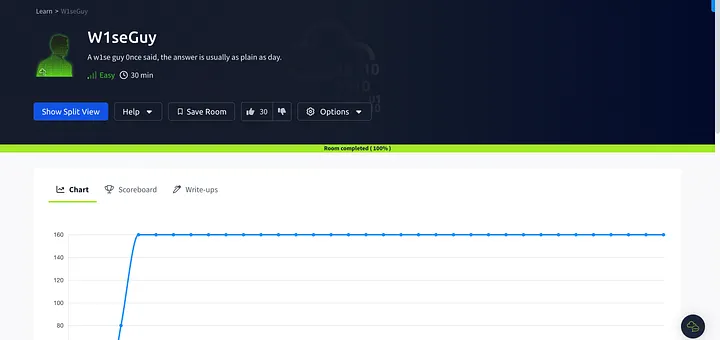

---

## Análise do Código-Fonte

O servidor é implementado em Python e utiliza `socketserver` para aceitar conexões TCP na porta **1337**.

Pontos importantes observados no código:

- A chave de criptografia é gerada aleatoriamente com **5 caracteres alfanuméricos**
- O algoritmo utilizado é **XOR com repetição da chave**
- Uma flag falsa (`THM{thisisafakeflag}`) é utilizada como texto conhecido
- O resultado do XOR é enviado ao usuário em formato hexadecimal
- O servidor solicita que o usuário informe a chave correta
- Caso a chave esteja correta, a flag real é revelada

In [ ]:
#Trecho relevante:

def setup(server, key):
    flag = 'THM{thisisafakeflag}' 
    xored = ""

    for i in range(0, len(flag)):
        xored += chr(ord(flag[i]) ^ ord(key[i % len(key)]))

    hex_encoded = xored.encode().hex()
    return hex_encoded

Esse processo combina cada caractere da flag falsa com um caractere da chave por meio da operação bit a bit XOR. A chave é repetida conforme necessário para cobrir o comprimento da flag. Em seguida, o texto cifrado é convertido para hexadecimal antes de ser exibido ao usuário.


O servidor então solicita que o usuário informe a chave original que foi gerada aleatoriamente. Se a entrada corresponder à chave correta, o servidor retorna a flag real armazenada no arquivo flag.txt.

---

### Recuperando a Primeira Flag

Após conectar ao serviço usando Netcat ou outra ferramenta TCP (por exemplo nc `10.10.216.214` 1337), o servidor envia uma mensagem contendo o texto XOR criptografado em formato hexadecimal. Sabemos que os flags do TryHackMe sempre começam com o prefixo padrão THM{, então podemos usar esse conhecimento como ponto de partida.


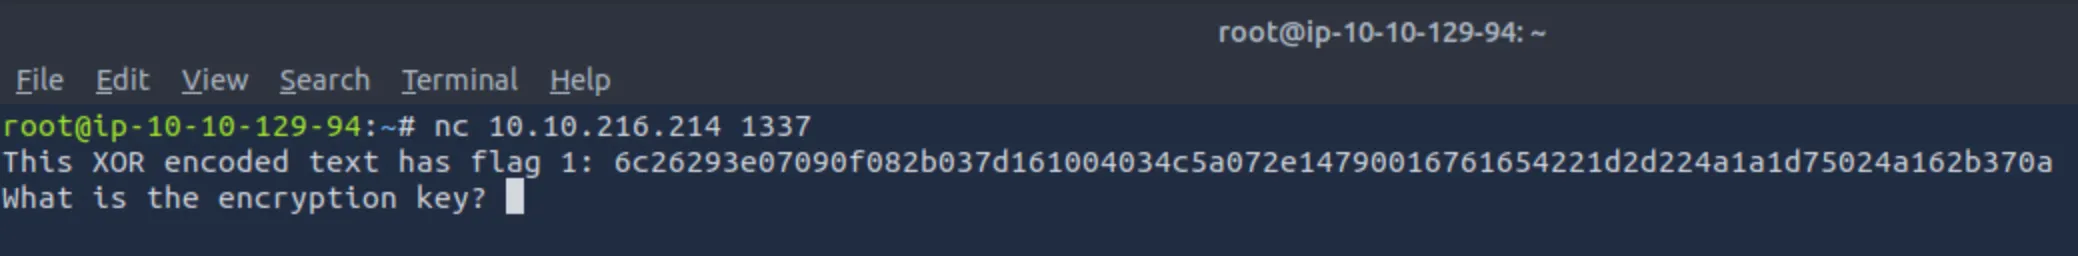

Ao converter os primeiros caracteres conhecidos (`T`, `H`, `M`, `{`) para valores hexadecimais e aplicá-los aos primeiros bytes da mensagem cifrada, obtemos parte da chave XOR usada pelo servidor. Em seguida, podemos estender esse processo para recuperar a chave completa de 5 caracteres.

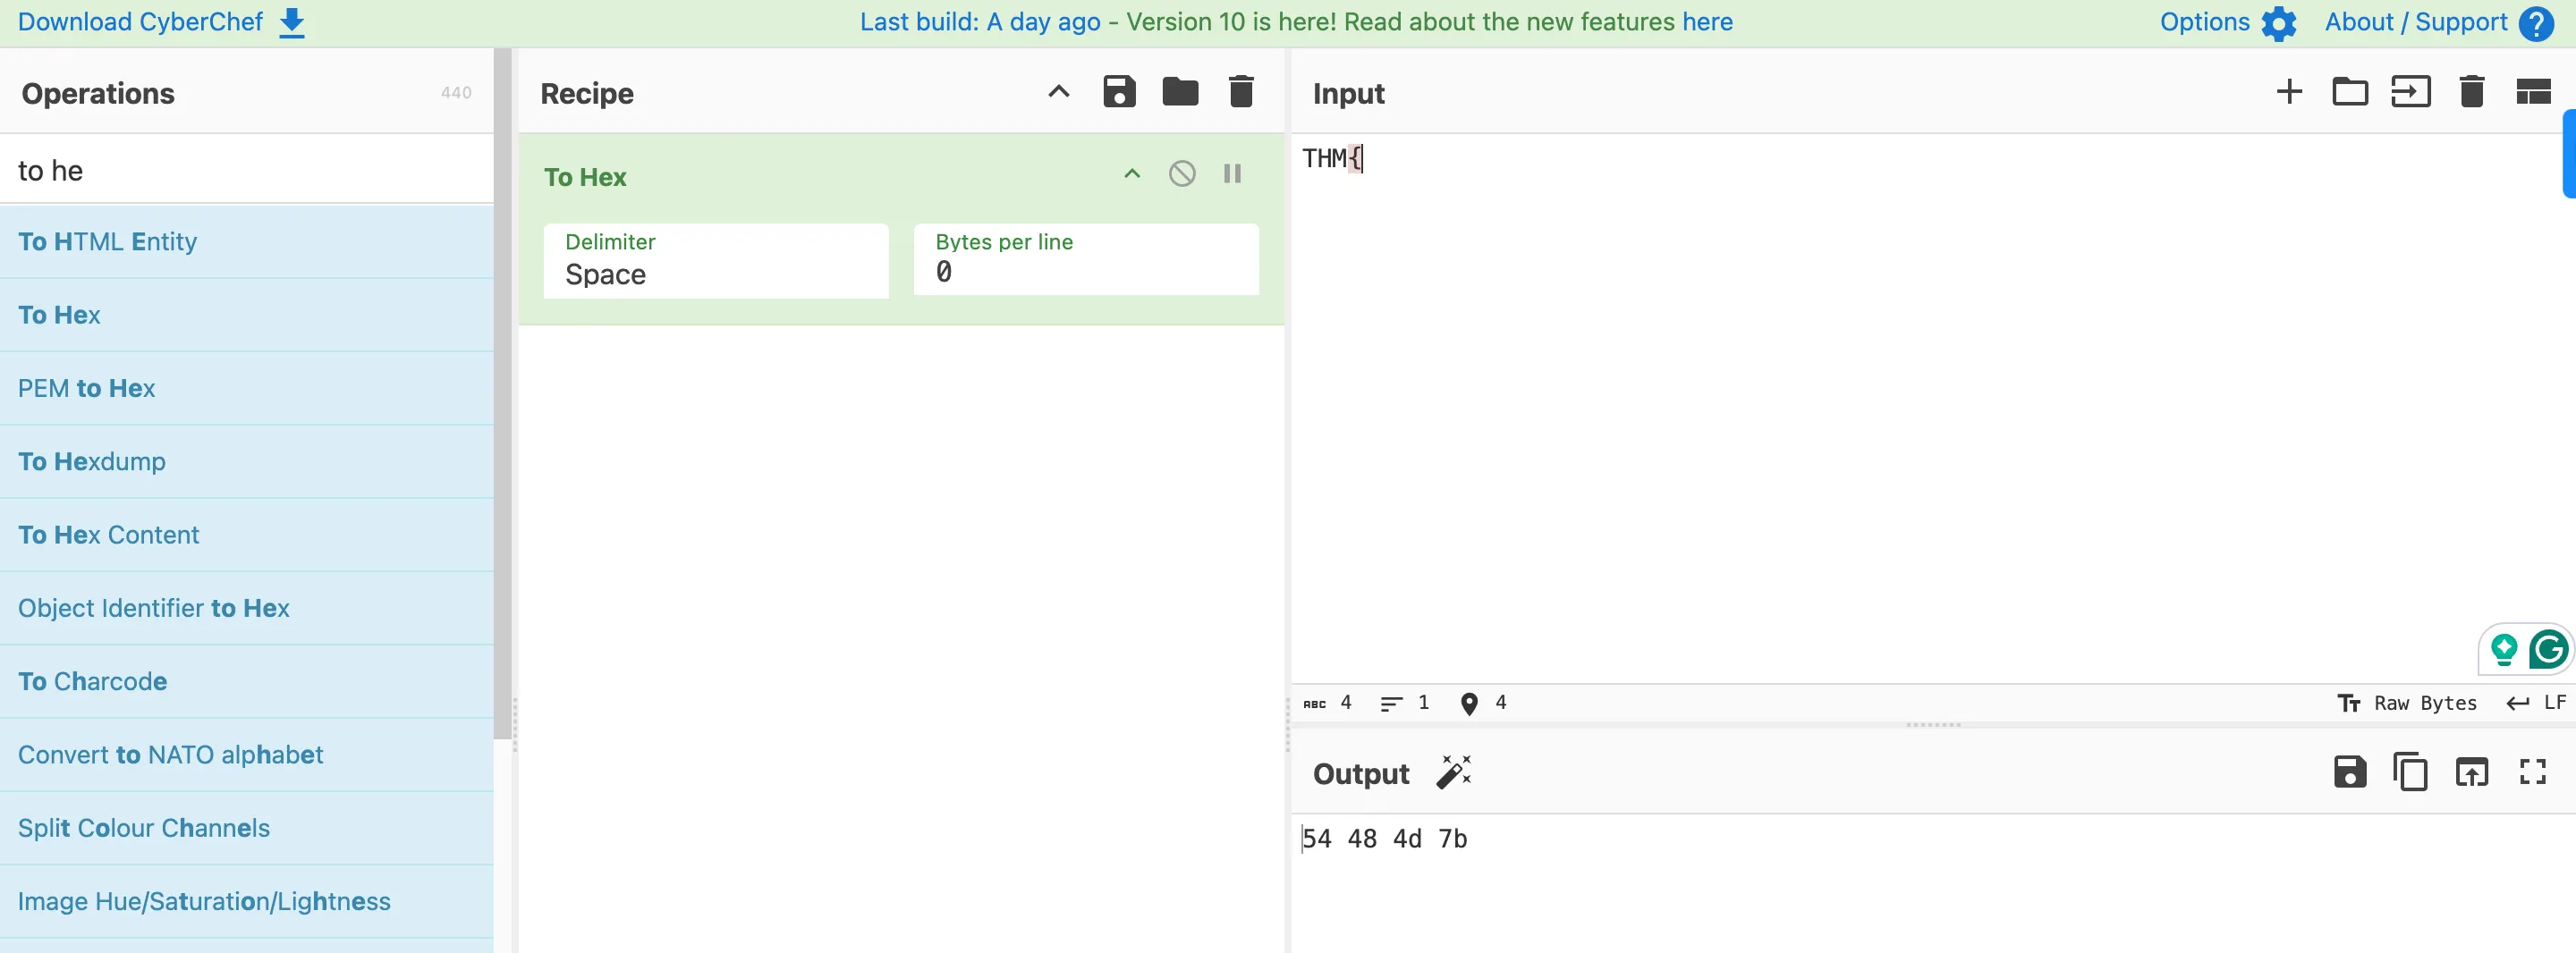

Portanto, agora podemos tentar a abordagem XOR reversa usando o texto que recebemos. Pegaremos os primeiros 4 bytes do texto gerado e usaremos isso como chave porque cada caractere em “THM{“ ocupa 1 byte (8 bits) da mensagem. No meu caso de acordo com a mensagem que recebi a chave seria **“6c26293e”** (pois estes são os primeiros 4 bytes do texto XORed).

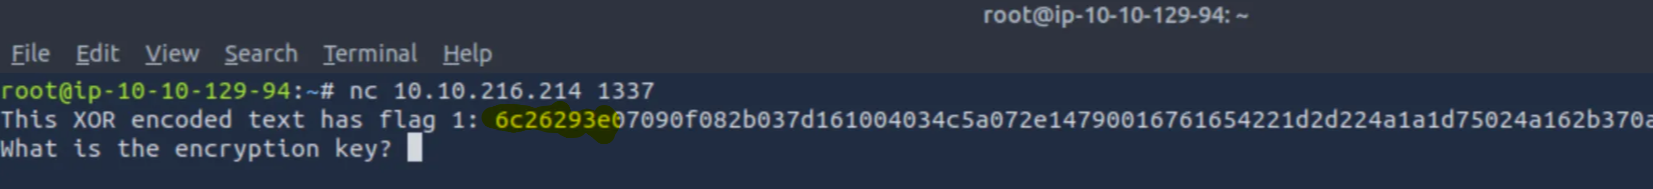

Agora, precisamos descobrir a que o “THM{“ original corresponde no formato XOR Encoded com a chave encontrada acima. Se descobrirmos isso, saberemos os primeiros 4 caracteres hexadecimais da chave criptografada. Isso é mostrado abaixo.

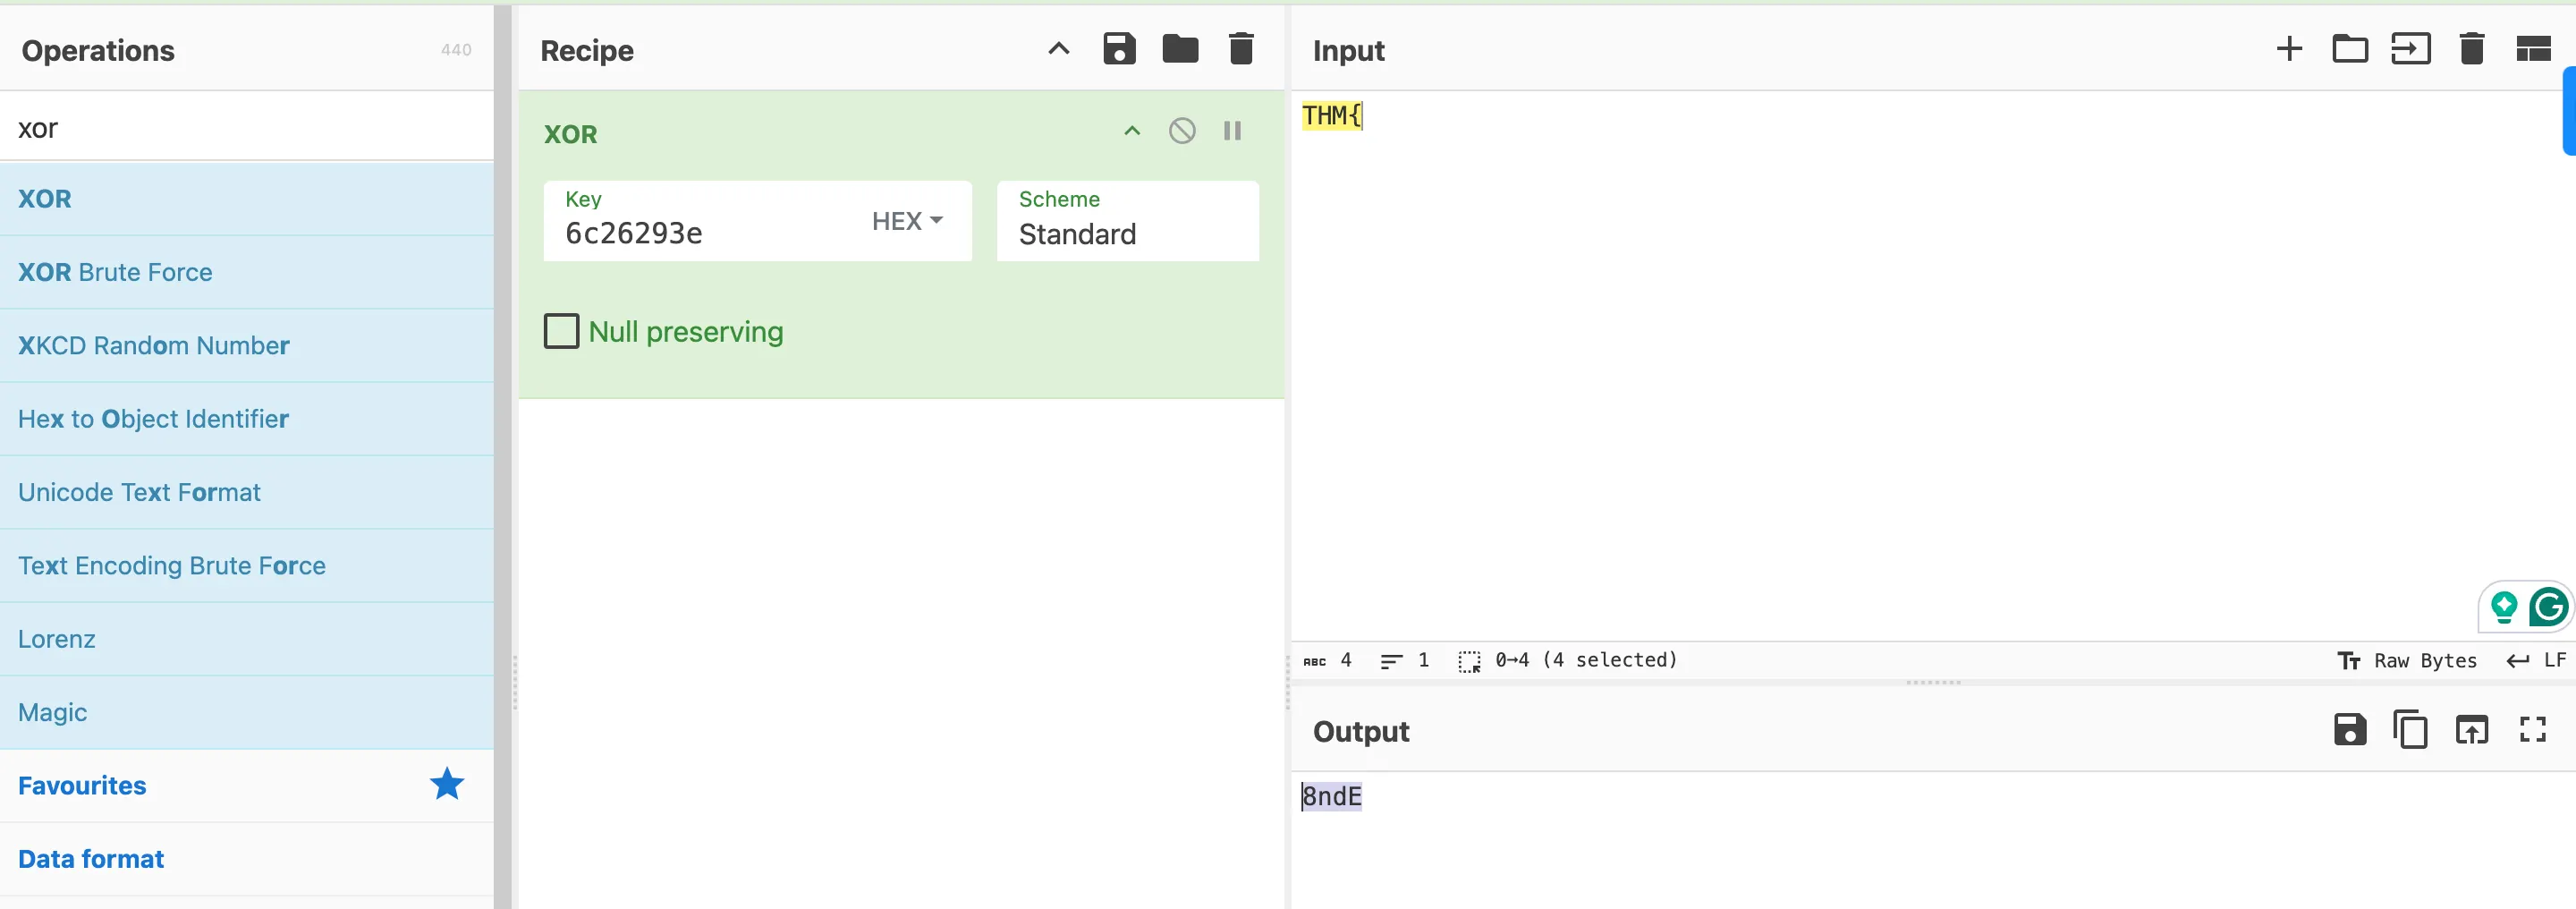

Como vemos na imagem, "THM{" com a key "6c26293e" equivale a: 8ndE. Estes são os primeiros 4 caracteres da nossa criptografia. Agora precisamos adicionar o texto XOR original junto a parte criptografada conforme mostrado abaixo. Preciso adicionar HEX e alterar o padrão XOR para UTF-8 para refletir a saída em XOR reversa.

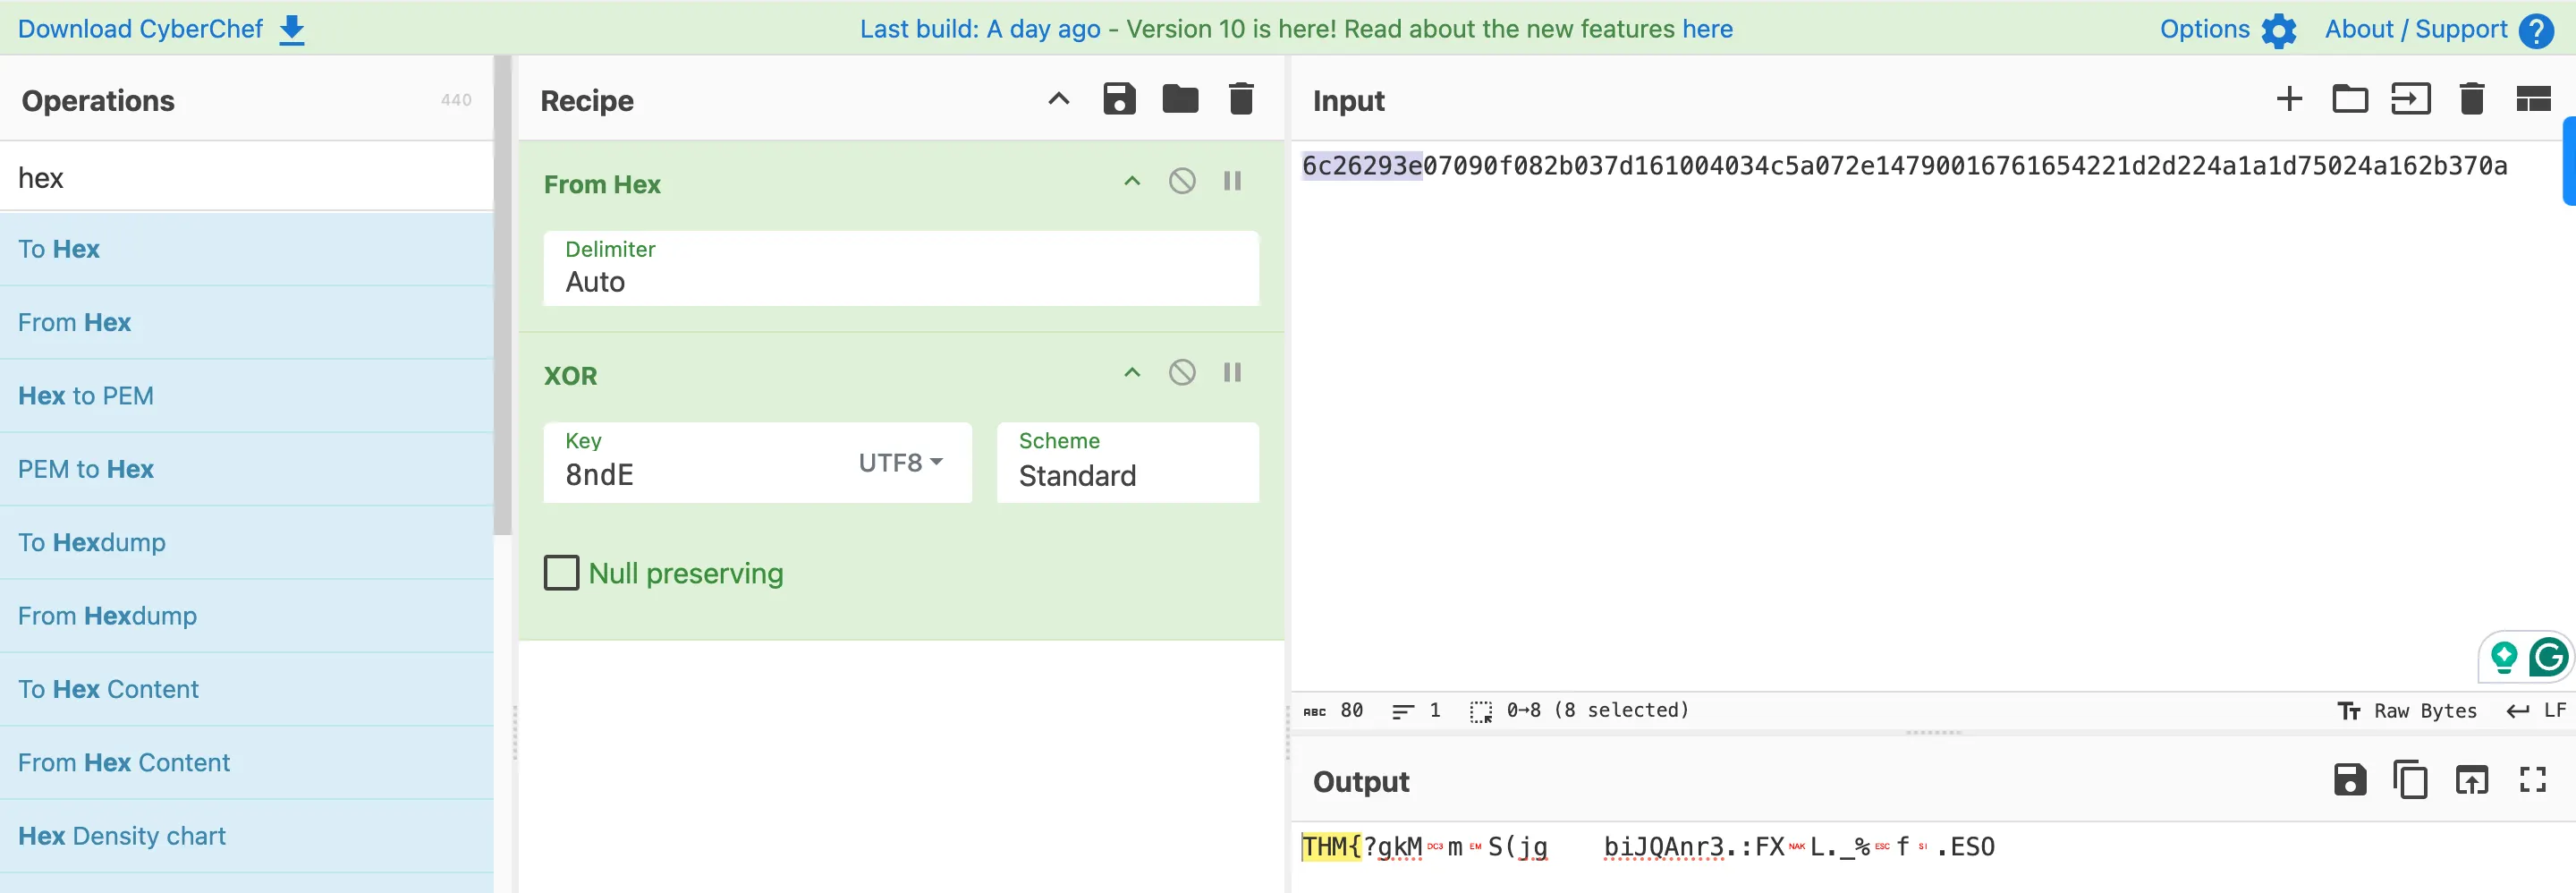

No caso desse "bruteforce", farei manualmente por tentativa e erro acrescentar um número ou letra, maiúscula ou minúscula a frente da Key XOR para descifrar a nossa primeira Flag.

---

Pós algumas tentativas, encontramos a nossa possível Flag e também nossa key do nosso netcat: "8ndEw"

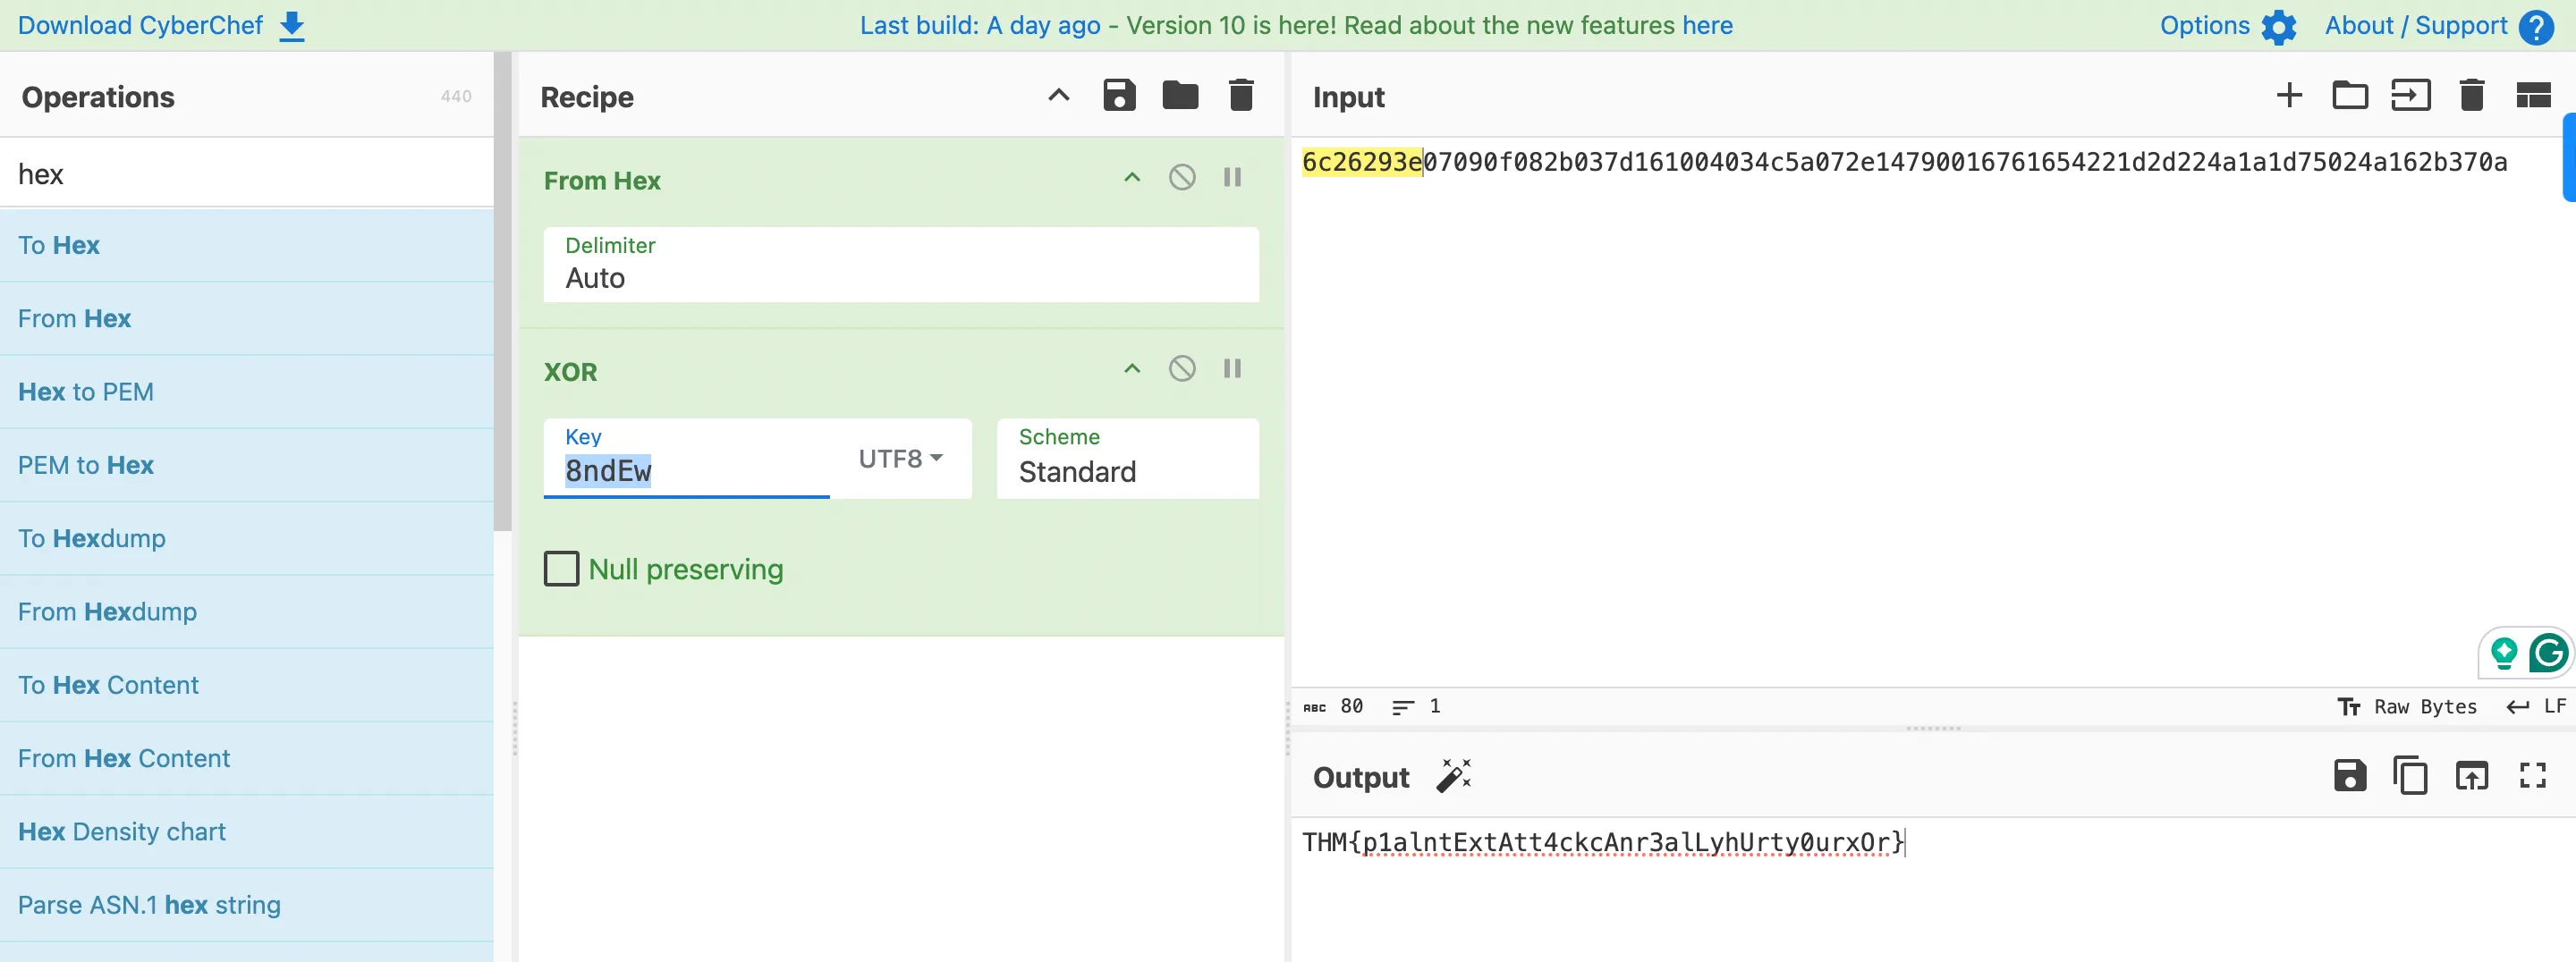

Primeira Flag:

In [ ]:
THM{p1alntExtAtt4ckcAnr3alLyhUrty0urxOr}

Agora vamos inserir nosso **8ndEw** no terminal com o `nc` para concluir nosso desafio.

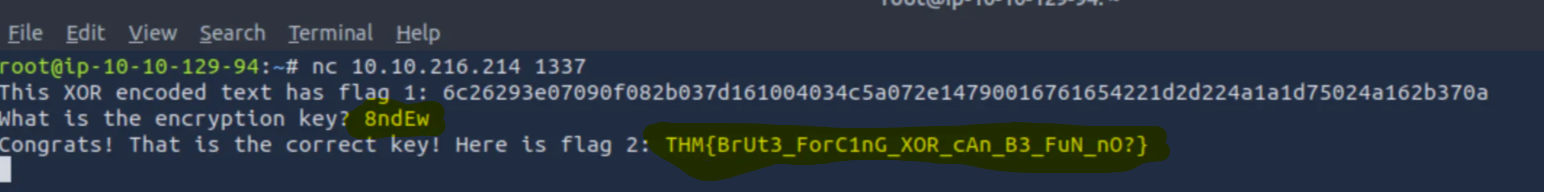

Segunda Flag:

In [ ]:
THM{BrUt3_ForC1nG_XOR_cAn_B3_FuN_nO?}